<a href="https://colab.research.google.com/github/Pauladrea03/SolarPV_Project/blob/main/b_Feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Introducción

El conjunto de datos proviene del sistema fotovoltaico del grupo GECAD (ISEP, Porto, Portugal). Este sistema estaba conformado inicialmente por dos paneles solares con una potencia total de 400 W. Sin embargo, tras la avería de uno de ellos el 4 de enero de 2013, la potencia instalada efectiva quedó reducida a aproximadamente 200 W. La información fue registrada con un periodo de muestreo de 5 minutos a lo largo de ese mismo año. En la literatura técnica, este dataset se ha empleado para la validación de modelos de celdas solares en PSCAD.

El propósito de este trabajo es predecir la generación de potencia eléctrica a partir de las variables más relevantes del dataset, disponible en el repositorio: https://site.ieee.org/pes-iss/data-sets/#ramos2012a
. En esta segunda etapa se lleva a cabo la ingeniería de características (feature engineering) aplicando distintas técnicas, las cuales permiten realizar la selección y extracción de características relevantes para lograr una buena predicción.

#Librerias

In [ ]:
# Librerías de manipulación de datos
import pandas as pd
import numpy as np

# Librerías de visualización
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display

# Librerías para estadística
import time
import math
from math import sqrt

# Librerías de machine learning y preprocesamiento
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn import metrics
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.linear_model import Lasso, Ridge, LinearRegression
from sklearn.feature_selection import RFE,SequentialFeatureSelector, SelectFromModel
from sklearn.model_selection import train_test_split

# Librerías para métricas de modelos
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

from sklearn.feature_selection import VarianceThreshold

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
from numpy.linalg import svd

import gdown
import sqlite3
from sklearn.model_selection import train_test_split
from math import sqrt
from xgboost import plot_importance
from xgboost.callback import EarlyStopping

#Carga de datos

In [ ]:
file_id = "1fAipOfV3JhNaUvHk9fmVshn-mMFPGfby" #identificador del archivo almacenado en google drive con acceso público
url = f"https://drive.google.com/uc?id={file_id}"
output = "data_final.db"
gdown.download(url, output, quiet=False)

# Conexión a la BD
conn = sqlite3.connect(output)

Downloading...
From: https://drive.google.com/uc?id=1fAipOfV3JhNaUvHk9fmVshn-mMFPGfby
To: /content/data_final.db
100%|██████████| 59.7M/59.7M [00:00<00:00, 98.2MB/s]


In [ ]:
# Cargar toda la tabla "registros" que se encuentra dentro de data_final.db a un DataFrame para su posterior análisis
df = pd.read_sql("SELECT * FROM df_FE;", conn)

conn.close()

print(df.shape)

(61152, 12)


#Presentación de base de datos

Con la finalidad de verificar y confirmar que en la etapa anterior se hizo un buen trabajo al eliminar algunas variables, se vuelven a considerar algunas de ellas, tales como energia_inyectada, frecuencia_red, numero_errores y tension_objetivo. A continuación se presenta estas variables y las variables que no se descartaron del EDA, con las cuales se va a trabajar en esta etapa.



* **radiacion_solar:** radiación solar real medida (W/m^2)
* **temperatura_modulo**: temperatura del módulo (°C)
* **corriente_ac**: corriente de red (A)
* **corriente_dc**: corriente en dc (A)
* **potencia_ac**: potencia AC generada (W)
* **tension_ac**: tensión de la red (V)
* **tension_dc**: tensión de entrada FV (V)
* **fecha**: fecha y hora combinadas en formato yyyy/mm/dd/ hh:mm:ss
* **energia_inyectada**: cantidad total de energía inyectada a la red (kWh)
* **frecuencia_red**: frecuencia de la red (Hz)
* **tension_objetivo**: tensión objetivo (V)
* **numero_errores**: número de errores ocurridos desde el último reinicio







In [ ]:
df.head()

,radiacion_solar,temperatura_modulo,energia_inyectada,frecuencia_red,numero_errores,corriente_ac,corriente_dc,potencia_ac,tension_ac,tension_dc,tension_objetivo,fecha
0,87.029147,16.367407,849.58904,18.952969,0.020528,14.027004,201.326461,3.363817,92.136134,9.188424,21.595039,2013-01-02 07:00:00
1,87.029147,16.367407,849.58904,18.952969,0.020528,14.027004,201.326461,3.363817,92.136134,9.188424,21.595039,2013-01-02 07:05:00
2,87.029147,16.367407,849.58904,18.952969,0.020528,14.027004,201.326461,3.363817,92.136134,9.188424,21.595039,2013-01-02 07:10:00
3,87.029147,16.367407,849.58904,18.952969,0.020528,14.027004,201.326461,3.363817,92.136134,9.188424,21.595039,2013-01-02 07:15:00
4,87.029147,16.367407,849.58904,18.952969,0.020528,14.027004,201.326461,3.363817,92.136134,9.188424,21.595039,2013-01-02 07:20:00


In [ ]:
df['fecha']=df['fecha'].astype('datetime64[ns]')

#Feature engineering

In [ ]:
#Variables temporales
# Extraer hora del día (en formato entero 0–23)
df['hora'] = df['fecha'].dt.hour
#Extraer solo la fecha
df['fecha_completa'] = df['fecha'].dt.date

In [ ]:
#Variables categoricas necesarias para el modelo
df['dia_semana'] = df['fecha'].dt.dayofweek  # 0=Lunes
df['mes'] = df['fecha'].dt.month #1=enero

In [ ]:
df['mes']=df['mes'].astype('category')
df['dia_semana']=df['dia_semana'].astype('category')
df['hora']=df['hora'].astype('category')

##Feature Selection

###Método de filtrado: Umbral de varianza

El método de umbral de varianza (Variance Threshold) es una técnica de filtrado utilizada para eliminar variables con poca variabilidad. Su fundamento estadístico radica en que una característica con varianza cercana a cero contiene poca información discriminativa, ya que su valor prácticamente no cambia a lo largo del tiempo o entre observaciones.

In [ ]:
df_int = df.select_dtypes(include = ["float64",'int32']) # filtrar solo variables númericas
df_int = df_int.drop('potencia_ac', axis = 1) # eliminar variable respuesta
y=df['potencia_ac']
df_int.head() # variables independientes númericas

,radiacion_solar,temperatura_modulo,energia_inyectada,frecuencia_red,numero_errores,corriente_ac,corriente_dc,tension_ac,tension_dc,tension_objetivo
0,87.029147,16.367407,849.58904,18.952969,0.020528,14.027004,201.326461,92.136134,9.188424,21.595039
1,87.029147,16.367407,849.58904,18.952969,0.020528,14.027004,201.326461,92.136134,9.188424,21.595039
2,87.029147,16.367407,849.58904,18.952969,0.020528,14.027004,201.326461,92.136134,9.188424,21.595039
3,87.029147,16.367407,849.58904,18.952969,0.020528,14.027004,201.326461,92.136134,9.188424,21.595039
4,87.029147,16.367407,849.58904,18.952969,0.020528,14.027004,201.326461,92.136134,9.188424,21.595039


In [ ]:
df_int.describe()

,radiacion_solar,temperatura_modulo,energia_inyectada,frecuencia_red,numero_errores,corriente_ac,corriente_dc,tension_ac,tension_dc,tension_objetivo
count,61152.000000,61152.000000,61152.000000,61152.000000,61152.000000,61152.00000,61152.000000,61152.000000,61152.000000,61152.000000
mean,429.283686,26.148543,1798.330759,39.640921,0.167709,300.65485,3649.950514,191.167926,18.516092,23.142320
std,369.655244,10.457750,887.876117,19.826157,2.096995,265.86668,3144.790049,95.621660,9.179789,18.139027
min,0.000000,2.710000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,52.850000,18.020000,2092.920000,49.258113,0.000000,0.79500,16.552500,235.475074,21.160000,21.650000
50%,361.665000,24.570000,2202.310000,49.980000,0.000000,263.56000,3283.870000,239.790000,22.620000,22.980000
75%,793.715000,33.452500,2310.275000,49.990000,0.000000,579.20000,6892.222500,242.230000,23.780000,24.060000
max,1256.360000,64.630000,2413.030000,56.220000,29.000000,1212.42000,14179.770000,252.280000,32.220000,79.000000


In [ ]:
# Función de filtro de caracteristicas
def variance_threshold(X,th): # recibe el dataframe y el umbral
    var_thres = VarianceThreshold(threshold=th) # crea la función con base en el umbral
    var_thres.fit(X) # alimenta los datos con la función creada
    new_cols = var_thres.get_support() # devuelve las columnas
    return new_cols

Antes de aplicar este método es necesario escalar todas las variables numéricas. Esto se debe a que las distintas magnitudes físicas del sistema fotovoltaico se expresan en unidades diferentes (por ejemplo, la irradiancia en W/m², la tensión en V, etc). Si se aplicara el filtro directamente sobre los datos originales, las variables de menor rango presentarán varianzas numéricamente pequeñas y serán eliminadas, aunque su variabilidad relativa dentro de su propio rango sea significativa.

Por tanto, se realizará un escalado (usando MinMaxScaler) para que todas las variables tengan varianzas comparables y el umbral de selección refleje únicamente su información verdadera y no su escala de medida. De esta manera, el análisis se centrará en identificar aquellas variables que efectivamente permanecen constantes en el tiempo, independientemente de su unidad física.

In [ ]:
# Normalicemos los datos con el rango
df_normalize = df_int.copy(deep = True)  # crear una copia del DataFrame
cols_excluir = ['hora_sin', 'hora_cos']
cols_a_escalar = [col for col in df_normalize.columns if col not in cols_excluir]
scaler = MinMaxScaler() # asignar el tipo de normalización
df_normalize[cols_a_escalar] = scaler.fit_transform(df_normalize[cols_a_escalar])
df_normalize.head()

,radiacion_solar,temperatura_modulo,energia_inyectada,frecuencia_red,numero_errores,corriente_ac,corriente_dc,tension_ac,tension_dc,tension_objetivo
0,0.069271,0.220565,0.352084,0.337121,0.000708,0.011569,0.014198,0.365214,0.285178,0.273355
1,0.069271,0.220565,0.352084,0.337121,0.000708,0.011569,0.014198,0.365214,0.285178,0.273355
2,0.069271,0.220565,0.352084,0.337121,0.000708,0.011569,0.014198,0.365214,0.285178,0.273355
3,0.069271,0.220565,0.352084,0.337121,0.000708,0.011569,0.014198,0.365214,0.285178,0.273355
4,0.069271,0.220565,0.352084,0.337121,0.000708,0.011569,0.014198,0.365214,0.285178,0.273355


In [ ]:
df_normalize.describe()

,radiacion_solar,temperatura_modulo,energia_inyectada,frecuencia_red,numero_errores,corriente_ac,corriente_dc,tension_ac,tension_dc,tension_objetivo
count,61152.000000,61152.000000,61152.000000,61152.000000,61152.000000,61152.000000,61152.000000,61152.000000,61152.000000,61152.000000
mean,0.341688,0.378529,0.745258,0.705104,0.005783,0.247979,0.257405,0.757761,0.574677,0.292941
std,0.294227,0.168891,0.367951,0.352653,0.072310,0.219286,0.221780,0.379030,0.284910,0.229608
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.042066,0.247255,0.867341,0.876167,0.000000,0.000656,0.001167,0.933388,0.656735,0.274051
50%,0.287867,0.353036,0.912674,0.889007,0.000000,0.217383,0.231588,0.950492,0.702048,0.290886
75%,0.631758,0.496487,0.957417,0.889185,0.000000,0.477722,0.486060,0.960163,0.738051,0.304557
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Tras la normalización de todas las variables numéricas del sistema fotovoltaico en un rango entre 0 y 1, se analizó la estadística descriptiva de cada característica para identificar su nivel de dispersión. En la Tabla de resultados, se observa que la mayoría de las variables presentan desviaciones estándar comprendidas entre 0.16 y 0.38. Con base en este análisis, se estableció un umbral de varianza equivalente al 16% de la desviación estándar máxima observada. Este valor se eligió de forma empírica como límite mínimo de variabilidad aceptable, ya que permite eliminar únicamente aquellas variables cuya variación temporal es significativamente menor que el comportamiento promedio del resto del sistema. De esta forma, se evita eliminar características con fluctuaciones reales, pero se filtran aquellas que aportan información redundante o prácticamente constante.

In [ ]:
# obtener columnas seleccionadas
desviacion = 0.16 # eliminar todo cuya desviación estandar sea menor
varianza = desviacion**2
print('Desviación estandar:', desviacion)
df_new = variance_threshold(df_normalize, varianza)
df_new_int = df_normalize.iloc[:,df_new] # nuevo dataframe
df_new_int.head()

Desviación estandar: 0.16


,radiacion_solar,temperatura_modulo,energia_inyectada,frecuencia_red,corriente_ac,corriente_dc,tension_ac,tension_dc,tension_objetivo
0,0.069271,0.220565,0.352084,0.337121,0.011569,0.014198,0.365214,0.285178,0.273355
1,0.069271,0.220565,0.352084,0.337121,0.011569,0.014198,0.365214,0.285178,0.273355
2,0.069271,0.220565,0.352084,0.337121,0.011569,0.014198,0.365214,0.285178,0.273355
3,0.069271,0.220565,0.352084,0.337121,0.011569,0.014198,0.365214,0.285178,0.273355
4,0.069271,0.220565,0.352084,0.337121,0.011569,0.014198,0.365214,0.285178,0.273355


Como resultado, el umbral de varianza permitió descartar la variable 'numero_errores' ya que esta tenía baja fluctuación temporal.

###Método de filtrado: Correlación de Pearson

Una vez aplicado el filtrado por varianza, se implementó un análisis de correlación lineal de Pearson con el objetivo de identificar relaciones lineales fuertes entre las variables del conjunto de datos y detectar posibles casos de multicolinealidad. En modelos predictivos de series temporales, la presencia de variables altamente correlacionadas puede generar redundancia, incrementar la complejidad del modelo y afectar la estabilidad de los coeficientes de regresión, dificultando la interpretación de los resultados.

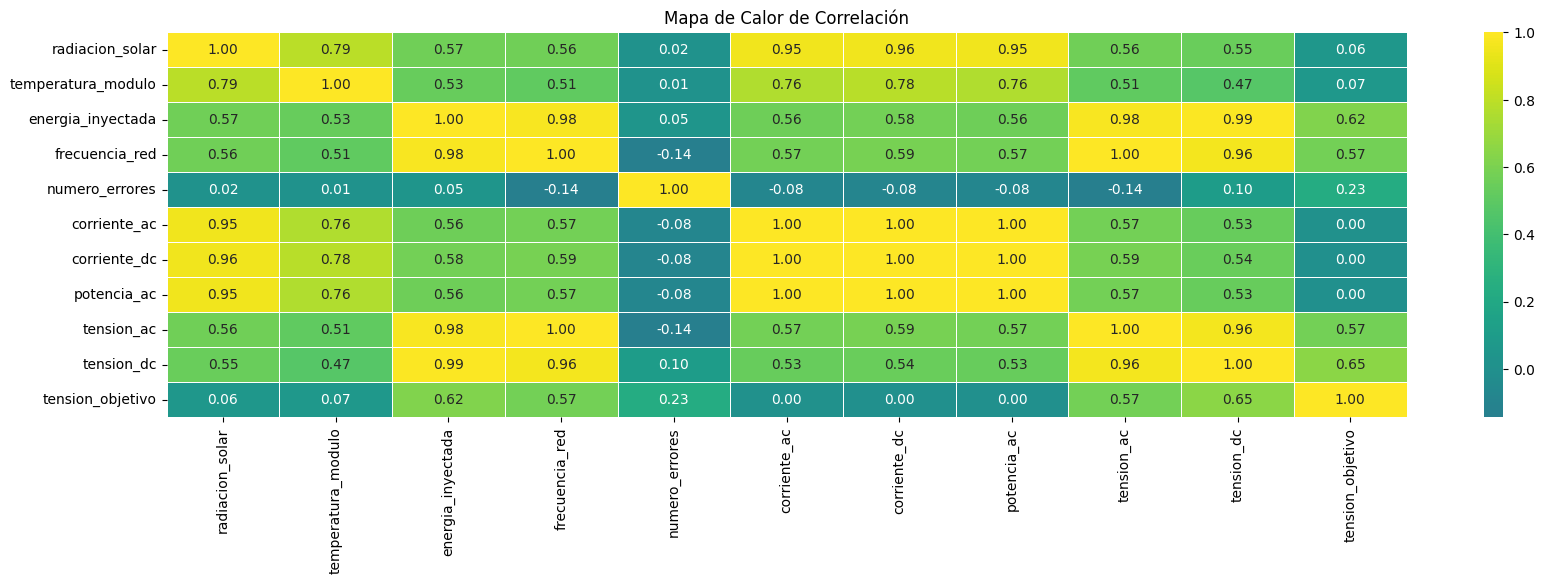

In [ ]:
def graficar_mapa_correlacion(df):
    # Seleccionar las columnas numéricas
    numeric_vars = df.select_dtypes(include=['number']).columns

    # Calcular la matriz de correlación
    corr_matrix = df[numeric_vars].corr(method='pearson')  # Correlación de Pearson

    # Crear el mapa de calor
    plt.figure(figsize=(20, 5))
    sns.heatmap(corr_matrix, annot=True, cmap='viridis', center=0, fmt='.2f', linewidths=0.5)
    plt.title('Mapa de Calor de Correlación')
    plt.show()

# Llamar a la función para generar el mapa de calor de correlación
graficar_mapa_correlacion(df)

In [ ]:
target = 'potencia_ac'
corr_target = df.corr(numeric_only=True)[target].sort_values(ascending=False)
print(corr_target.head(21))

potencia_ac           1.000000
corriente_ac          0.999860
corriente_dc          0.997736
radiacion_solar       0.953963
temperatura_modulo    0.758776
tension_ac            0.572824
frecuencia_red        0.572646
energia_inyectada     0.560236
tension_dc            0.532608
tension_objetivo      0.003059
numero_errores       -0.081244
Name: potencia_ac, dtype: float64


En la Figura anterior se muestra el mapa de calor de correlación de Pearson para las variables del sistema. Este gráfico permite visualizar de manera global las dependencias entre las diferentes características. Se observa que existe una fuerte correlación entre varias variables, con valores de r superiores a 0.95, especialmente entre:

*   tension_ac, tension_dc y frecuencia_red
*   corriente_ac, corriente_dc y potencia_ac
*   radiacion_solar con las corrientes y la potencia generada.

Estos resultados son coherentes con la funcionalidad del sistema: la potencia generada depende directamente de la radiación solar y de las condiciones de tensión y corriente de los módulos fotovoltaicos. Sin embargo, cuando múltiples variables representan esencialmente el mismo fenómeno, su inclusión simultánea en el modelo puede resultar redundante y no aportar nueva información.

Para evitar la multicolinealidad, se adoptó como criterio de eliminación un umbral de correlación de |r| > 0.85. En estos casos, se conservaron únicamente las variables con mayor representatividad física y relevancia en el contexto del modelo de predicción de potencia. A partir de este análisis, se decidió eliminar las siguientes características:

tension_objetivo: Aunque muestra cierta relación con tension_dc, esta es la tensión objetivo del inversor, no la tensión real de los paneles. El inversor ajusta la tensión de operación para optimizar la potencia, por lo que la variable clave es la tensión real, no la deseada.

corriente_ac y corriente_dc: Ambas variables presentan una correlación casi perfecta entre sí (r ≈ 1.00) y con la potencia (r ≈ 1.00), lo que las hace redundantes. Se conservó únicamente la potencia como variable representativa de este grupo.

frecuencia_red: Altamente correlacionada con tension_ac (r ≈ 1.00) y con muy poca variabilidad a lo largo del tiempo, por lo que no aporta información adicional.

In [ ]:
df_filt=df.drop(columns=['numero_errores','tension_objetivo','corriente_ac','corriente_dc','frecuencia_red'])

###Método Wrapper: Sequential Feature Selection

Después de aplicar los métodos de filtrado se implementó una técnica de selección secuencial de características (Sequential Feature Selection). Este método wrapper utiliza un modelo predictivo para evaluar iterativamente la contribución de cada variable al desempeño del modelo.

El SFS consiste en seleccionar, de manera progresiva, las variables que mejoran el ajuste de un modelo base, en este caso una Regresión Lineal, que permite analizar la contribución de las variables bajo un supuesto de relación lineal con la variable objetivo (potencia_ac). En el enfoque de selección hacia adelante (forward selection), el algoritmo comienza con un conjunto vacío de variables y, en cada iteración, agrega aquella característica que produce la mayor mejora en la métrica de evaluación. Este proceso continúa hasta alcanzar el número de variables especificado o hasta que no se observe una mejora significativa en el desempeño del modelo.

In [ ]:
#se excluyeron las variables temporales de este analisis
fixed_temporal_features = ['fecha','fecha_completa','hora','dia_semana','mes']
features_to_select = [col for col in df_filt.columns if col not in fixed_temporal_features]

In [ ]:
###Normalización de variables numéricas
dfc=df_filt[features_to_select].copy()
dfc=dfc.drop(['potencia_ac'],axis=1) #variables de interés para el modelo
def preprocess_features(df):
    # Identificar columnas numéricas
    numcol = [col for col in df.columns if df[col].dtype == "float64"]

    # Aplicar Min-Max Scaling
    scaler = MinMaxScaler()
    df[numcol] = scaler.fit_transform(df[numcol])

    return df

x_features_dum=dfc.copy()
x_features_dum=preprocess_features(x_features_dum)

In [ ]:
x_features_dum.columns

Index(['radiacion_solar', 'temperatura_modulo', 'energia_inyectada',
       'tension_ac', 'tension_dc'],
      dtype='object')

In [ ]:
# Selector secuencias utilizando regresión lineal
sfs = SequentialFeatureSelector(LinearRegression(), #regresión lineal múltiple como modelo base para cuantificar la capacidad explicativa de cada combinación de variables.
                                n_features_to_select=4, #se seleccionarán 4 variables debido a la poca cantidad existente de variables que tenemos
                                direction= "forward",  #se selecciona seleccion hacia delante o eliminacion hacia atras
                                scoring='r2') #mide la proporción de la variabilidad de la potencia explicada por las variables seleccionadas.
# Obtener variable seleccionadas
sfs = sfs.fit(x_features_dum, y)
X_new = sfs.support_
df_new = x_features_dum.iloc[:,X_new]
df_new.head()

,radiacion_solar,temperatura_modulo,tension_ac,tension_dc
0,0.069271,0.220565,0.365214,0.285178
1,0.069271,0.220565,0.365214,0.285178
2,0.069271,0.220565,0.365214,0.285178
3,0.069271,0.220565,0.365214,0.285178
4,0.069271,0.220565,0.365214,0.285178


La variable 'energia_inyectada' representa un valor acumulado de la energía total entregada a la red, y no una magnitud instantánea, por lo que su inclusión podría inducir dependencia temporal y sesgo en la predicción.

In [ ]:
selected_columns = np.array(x_features_dum.columns)[sfs.get_support()]
final_features = list(selected_columns) + fixed_temporal_features
df_final = df_filt[final_features + ['potencia_ac']]  # Incluye la variable objetivo para referencia

In [ ]:
df_final.head()

,radiacion_solar,temperatura_modulo,tension_ac,tension_dc,fecha,fecha_completa,hora,dia_semana,mes,potencia_ac
0,87.029147,16.367407,92.136134,9.188424,2013-01-02 07:00:00,2013-01-02,7,2,1,3.363817
1,87.029147,16.367407,92.136134,9.188424,2013-01-02 07:05:00,2013-01-02,7,2,1,3.363817
2,87.029147,16.367407,92.136134,9.188424,2013-01-02 07:10:00,2013-01-02,7,2,1,3.363817
3,87.029147,16.367407,92.136134,9.188424,2013-01-02 07:15:00,2013-01-02,7,2,1,3.363817
4,87.029147,16.367407,92.136134,9.188424,2013-01-02 07:20:00,2013-01-02,7,2,1,3.363817


##Feature extraction

###Métodos lineales

####PCA

Como parte del proceso de extracción de características, se aplicó el Análisis de Componentes Principales (PCA) con el propósito de identificar combinaciones lineales de variables que concentraran la mayor parte de la varianza total del sistema fotovoltaico. El PCA es una técnica estadística de reducción de dimensionalidad que transforma las variables originales en un nuevo conjunto de componentes ortogonales, no correlacionadas entre sí, denominadas componentes principales. Estas componentes representan las direcciones de máxima variabilidad en los datos y permiten sintetizar la información contenida en múltiples variables en un espacio reducido.

In [ ]:
#PCA
pca_full = PCA(random_state=102)
pca_full.fit(df_new)

PCA(random_state=102)

El método se basa en la descomposición espectral de la matriz de covarianza de los datos estandarizados. Matemáticamente, las componentes principales se obtienen como los vectores propios de dicha matriz, ordenados según los valores propios decrecientes (autovalores), los cuales indican la cantidad de varianza explicada por cada componente.

Para este análisis, se utilizaron las variables previamente seleccionadas mediante SFS: radiacion_solar, temperatura_modulo, tension_ac y tension_dc. Todas las variables fueron escaladas mediante estandarización (media cero y varianza unitaria), con el fin de asegurar que cada una contribuyera de manera equitativa a la construcción de las componentes.

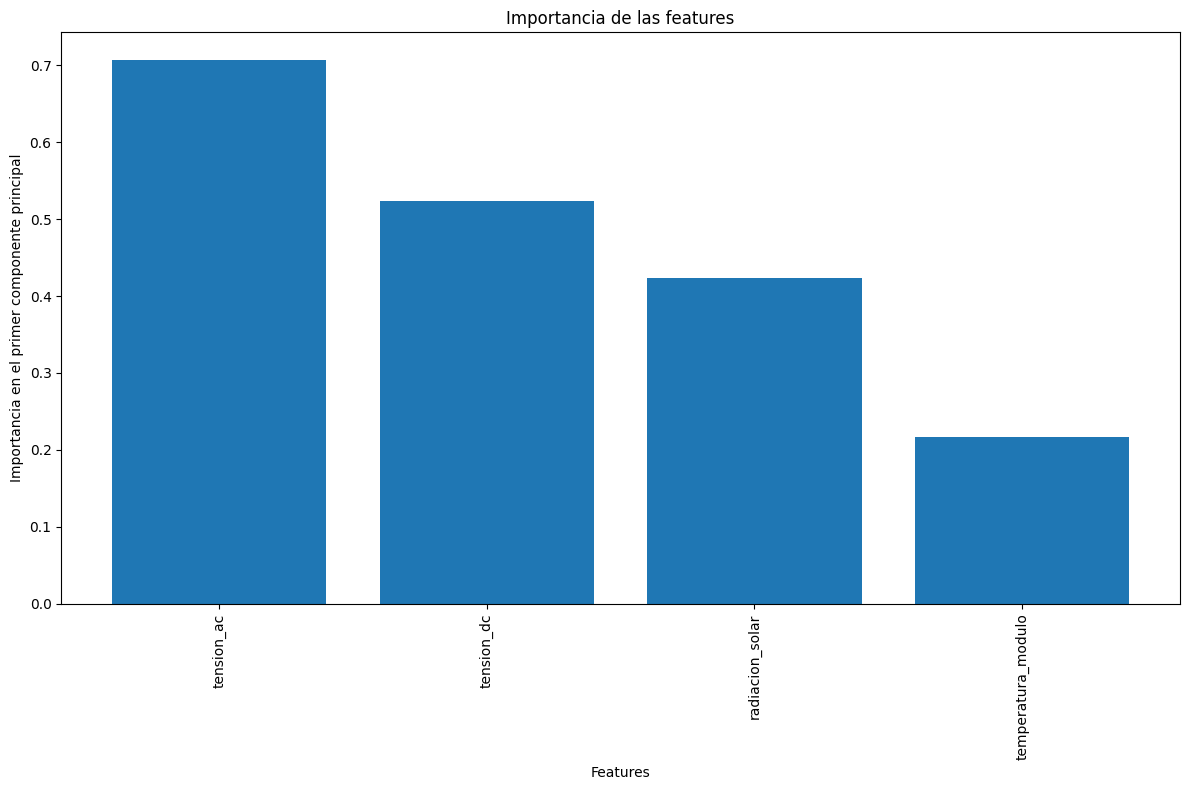

In [ ]:
# Creación de dataframe de variables importantes
feature_importance = pd.DataFrame({
    'feature': df_new.columns,
    'importance': np.abs(pca_full.components_[0])
})
feature_importance = feature_importance.sort_values('importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 8))
plt.bar(feature_importance['feature'], feature_importance['importance'])
plt.xticks(rotation=90)
plt.xlabel('Features')
plt.ylabel('Importancia en el primer componente principal')
plt.title('Importancia de las features')
plt.tight_layout()
plt.show()

In [ ]:
varianza_exp = pca_full.explained_variance_ratio_
varianza_exp #varianza explicada por cada componente

array([0.78887185, 0.17447971, 0.02554522, 0.01110321])

In [ ]:
# Varianza explicada acumulada
varianza_acum = np.cumsum(varianza_exp)
varianza_acum

array([0.78887185, 0.96335156, 0.98889679, 1.        ])

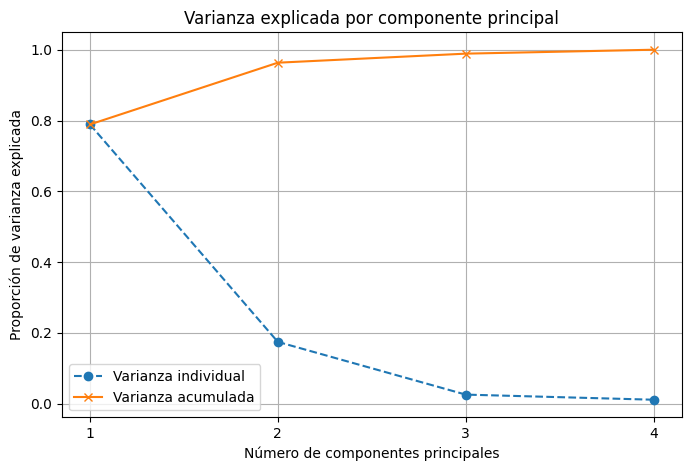

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(varianza_exp) + 1), varianza_exp, marker='o', linestyle='--', label='Varianza individual')
plt.plot(range(1, len(varianza_acum) + 1), varianza_acum, marker='x', linestyle='-', label='Varianza acumulada')
plt.title('Varianza explicada por componente principal')
plt.xlabel('Número de componentes principales')
plt.ylabel('Proporción de varianza explicada')
plt.xticks(range(1, len(varianza_acum) + 1))
plt.legend()
plt.grid(True)
plt.show()

El gráfico de varianza explicada mostró que la primera componente principal (PC1) concentra aproximadamente el 80 % de la varianza total, mientras que la segunda componente (PC2) eleva la varianza acumulada hasta cerca del 98 %. Las siguientes componentes aportan una fracción mínima de información (cerca al 2%). Esto sugiere que las dos primeras componentes son suficientes para describir la estructura lineal dominante del sistema.

In [ ]:
n_componentes = 2 #Se eligen dos componentes principales
pca = PCA(n_components=n_componentes, random_state=102)
X_pca = pca.fit_transform(df_new)

X_pca_df = pd.DataFrame(X_pca, columns=[f"PC_{i+1}" for i in range(n_componentes)])

print(f"Tamaño del dataset transformado: {X_pca_df.shape}")

X_pca_df

Tamaño del dataset transformado: (61152, 2)


,PC_1,PC_2
0,-0.578615,-0.044486
1,-0.578615,-0.044486
2,-0.578615,-0.044486
3,-0.578615,-0.044486
4,-0.578615,-0.044486
...,...,...
61147,-1.027112,0.100294
61148,-1.026587,0.101245
61149,-1.026517,0.101372
61150,-1.026413,0.101562


In [ ]:
# 1. Obtener los nombres de las variables originales
nombres_variables = df_new.columns

# 2. Crear un DataFrame con los loadings
# Se transpone (T) la matriz components_ para tener variables como filas y PCs como columnas
loadings_df = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC_{i+1}" for i in range(n_componentes)],
    index=nombres_variables
)

print("\nMatriz de cargas:")
loadings_df


Matriz de cargas:


,PC_1,PC_2
radiacion_solar,0.423536,0.786975
temperatura_modulo,0.216414,0.392559
tension_ac,0.707307,-0.369381
tension_dc,0.522972,-0.300210


Interpretación de las componentes principales:

El análisis aplicado sobre las variables físicas del sistema fotovoltaico permitió reducir la dimensionalidad del conjunto de datos a dos componentes principales que explican la mayor parte de la varianza total.

La primera componente (PC1) está fuertemente asociada con las variables de tensión AC (0.708), tensión DC (0.523) y radiación solar (0.422). Esta componente representa el nivel general de operación eléctrica del sistema, capturando el patrón diario de generación de potencia.

La segunda componente (PC2) presenta cargas positivas en radiación solar (0.787) y temperatura del módulo (0.393), pero negativas en tensiones AC y DC. Este patrón indica un efecto térmico inverso: al aumentar la radiación y la temperatura, disminuye ligeramente la tensión del sistema PV, reflejando una pérdida de eficiencia en los módulos.

En conjunto, PC1 y PC2 capturan las principales dinámicas del sistema: la variación diaria de la generación solar y el impacto de la temperatura en la eficiencia.

In [ ]:
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['fecha'] = df_filt['fecha']
pca_df['hora'] = df_filt['hora']
pca_df['mes'] = df_filt['mes']

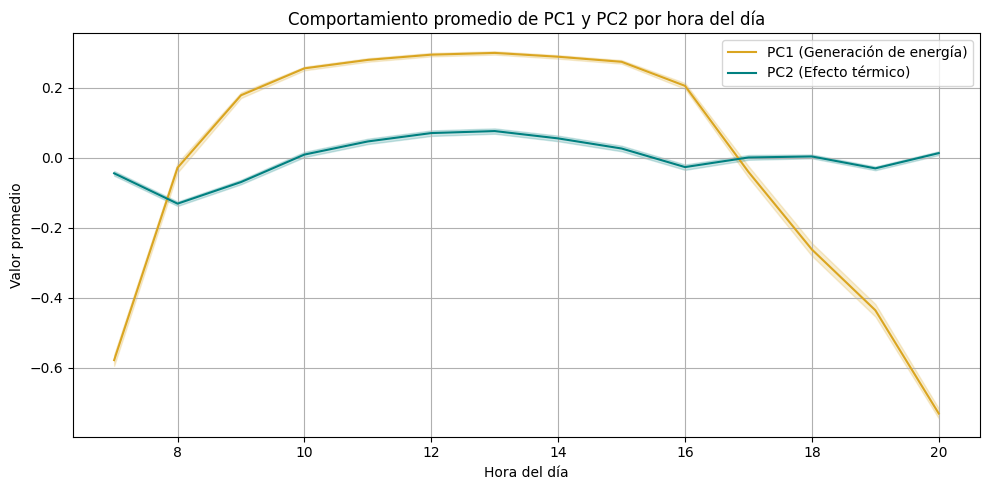

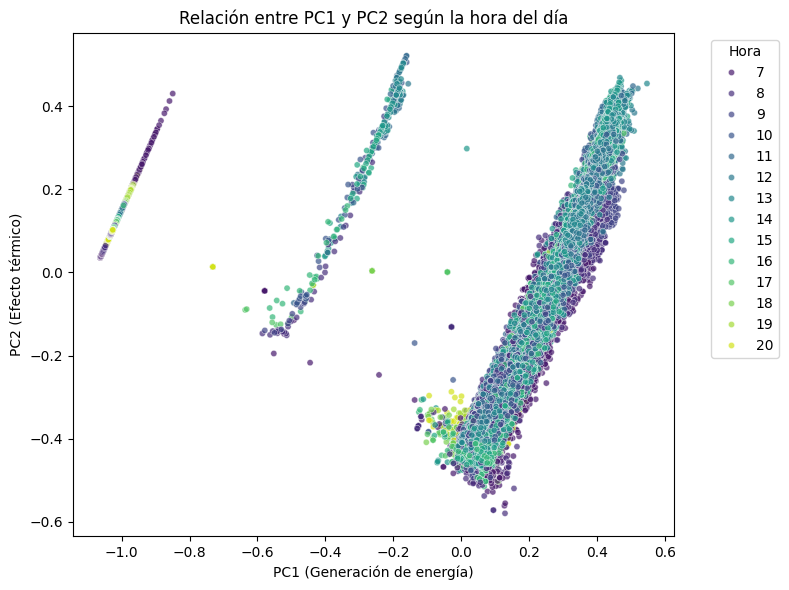

In [ ]:
# Promedio de PC1 y PC2 por hora del día
plt.figure(figsize=(10,5))
sns.lineplot(data=pca_df, x='hora', y='PC1', label='PC1 (Generación de energía)', color='goldenrod')
sns.lineplot(data=pca_df, x='hora', y='PC2', label='PC2 (Efecto térmico)', color='teal')
plt.title('Comportamiento promedio de PC1 y PC2 por hora del día')
plt.xlabel('Hora del día')
plt.ylabel('Valor promedio')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Relación entre PC1 y PC2 coloreada por hora
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='hora',
                palette='viridis', alpha=0.7, s=20)
plt.title('Relación entre PC1 y PC2 según la hora del día')
plt.xlabel('PC1 (Generación de energía)')
plt.ylabel('PC2 (Efecto térmico)')
plt.legend(title='Hora', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Las figuras muestran el comportamiento promedio diario de ambas componentes agrupado por hora del día. Se observa que la primera componente (PC1) presenta una evolución de una variable de carácter solar porque tiene valores negativos o cercanos a cero durante las primeras horas del día, un ascenso progresivo a medida que aumenta la radiacion solar y un descenso simétrico hacia la tarde. Esta forma describe con claridad el ciclo diario de generación eléctrica, por lo que PC1 puede interpretarse como una componente solar o de potencia.

Por otro lado, la segunda componente (PC2) mantiene una forma más suave y estable durante el día, con valores ligeramente negativos en las horas de baja irradiancia y positivos alrededor del mediodía. Este comportamiento refleja principalmente el efecto térmico de la temperatura del módulo sobre la eficiencia del sistema, lo que justifica su interpretación como una componente térmica. En conjunto, ambas componentes sintetizan la interacción entre la energía incidente y la respuesta térmica del sistema fotovoltaico.

El PCA permitió identificar la estructura lineal dominante del sistema y reducir la dimensionalidad a dos variables sintéticas que explican la mayor parte de la variabilidad. Sin embargo, este método presenta limitaciones importantes cuando se aplica a series temporales.

En particular:

*   El PCA no conserva la dependencia temporal de los datos, ya que trata las observaciones como independientes entre sí.

*   La variabilidad capturada refleja la covarianza global, pero no la dinámica secuencial ni los efectos de tendencia, periodicidad o estacionalidad característicos de una serie de tiempo.

En el caso del sistema fotovoltaico, la variabilidad está fuertemente asociada a ciclos diarios y estacionales, los cuales requieren métodos que preserven la estructura temporal para su adecuada representación.

####SSA

El Singular Spectrum Analysis (SSA) es una técnica no paramétrica para el análisis y descomposición de series temporales que combina conceptos de análisis espectral, geometría lineal y teoría de sistemas dinámicos. Su objetivo principal es separar una señal compleja en componentes interpretables (tendencia, oscilaciones periódicas y ruido) preservando la estructura temporal de los datos.

A diferencia del PCA, que busca maximizar la varianza en un espacio de variables independientes, el SSA opera directamente sobre la secuencia temporal, descomponiendo la serie en función de su autocorrelación. Esto lo convierte en un método mucho más adecuado para series de tiempo, donde los fenómenos de interés (variación solar, ciclos diarios y efectos estacionales) están intrínsecamente ligados al tiempo.

Para este análisis se utilizó la serie temporal de potencia AC de un sistema fotovoltaico muestreada cada 30 minutos, con el fin de reducir la carga computacional y evitar problemas de memoria (el conjunto original registra mediciones cada 5 minutos).

Se definió una ventana de longitud L=140, equivalente a cinco días de observaciones solares (considerando 28 muestras por día). Este tamaño de ventana permite capturar simultáneamente las variaciones de corto plazo (ciclo diario) y las de mediano plazo (tendencia semanal).

El procedimiento se implementó con ayuda del siguiente notebook público de kaggle https://www.kaggle.com/code/leokaka/pca-for-time-series-analysis/notebook y los pasos a seguir fueron:

1.  Construcción de la matriz trayectoria X.

2.  Aplicación de la descomposición SVD para obtener los valores y vectores singulares.

3.  Reconstrucción de las componentes elementales mediante promediado Hankel.

4.  Agrupación de componentes según su interpretación física:

Tendencia: primera componente

Ciclo diario: componentes 2 y 3

Ruido residual: componentes restantes

N = 10192, L = 140, K = 10053
Componentes calculadas: 140


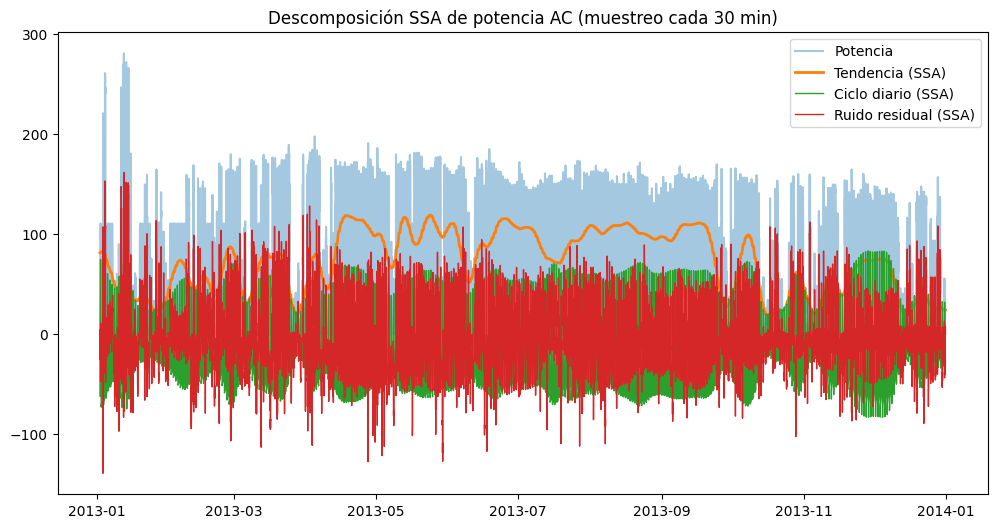

In [ ]:

#Submuestrear cada 30 minutos por motivos de memoria RAM
df_sub = df_final.iloc[::6].reset_index(drop=True)
serie = df_sub['potencia_ac'].values
N = len(serie)

#Definir ventana (5 días)
L = 140   # 28*5 (28 puntos=1 día solar)
K = N - L + 1
print(f"N = {N}, L = {L}, K = {K}")

#Matriz trayectoria (Hankel)
X = np.column_stack([serie[i:i+L] for i in range(K)])

#Descomposición SVD (SSA)
U, s, VT = svd(X)
d = len(s)
print(f"Componentes calculadas: {d}")

#Matrices elementales
X_elem = np.array([s[i] * np.outer(U[:, i], VT[i, :]) for i in range(d)])

#Reconstrucción de cada componente
def hankel_to_series(X_elem):
    L, K = X_elem.shape
    N = L + K - 1
    series = np.zeros(N)
    counts = np.zeros(N)
    for i in range(L):
        for j in range(K):
            series[i+j] += X_elem[i, j]
            counts[i+j] += 1
    return series / counts

components = np.array([hankel_to_series(X_elem[i]) for i in range(d)])

#Agrupar componentes
F_trend = components[0]
F_periodic = components[1:3].sum(axis=0)
F_noise = components[3:].sum(axis=0)

#Agregar las nuevas variables al DataFrame submuestreado
df_sub['tendencia_potencia'] = F_trend
df_sub['periodo_potencia'] = F_periodic
df_sub['ruido_potencia'] = F_noise

#Graficar resultados
plt.figure(figsize=(12,6))
plt.plot(df_sub['fecha'], df_sub['potencia_ac'], label='Potencia', alpha=0.4)
plt.plot(df_sub['fecha'], df_sub['tendencia_potencia'], label='Tendencia (SSA)', linewidth=2)
plt.plot(df_sub['fecha'], df_sub['periodo_potencia'], label='Ciclo diario (SSA)', linewidth=1)
plt.plot(df_sub['fecha'], df_sub['ruido_potencia'], label='Ruido residual (SSA)', linewidth=1)
plt.title("Descomposición SSA de potencia AC (muestreo cada 30 min)")
plt.legend()
plt.show()


La figura muestra la descomposición de la potencia AC en sus componentes SSA.

La serie original (azul claro) exhibe la variabilidad diaria de la generación fotovoltaica.

La tendencia (línea naranja) representa el comportamiento de largo plazo del sistema, capturando fluctuaciones graduales a lo largo de los meses. Se observan variaciones estacionales en la radiación, con mayor producción entre abril y septiembre, coincidiendo con periodos de mayor irradiancia.

El ciclo diario (línea verde) refleja las oscilaciones periódicas asociadas al amanecer y atardecer, con una forma sinusoidal truncada, que coincide con el patrón de generación solar.

El ruido residual (línea roja) corresponde a fluctuaciones rápidas no periódicas, posiblemente debidas a efectos de sombreados parciales, variaciones instantáneas en la carga o ruido.

Este resultado demuestra que el SSA permite separar de manera clara y visual los diferentes niveles de estructura temporal presentes en la potencia AC, algo que métodos puramente lineales (como PCA) no logran captar.

A continuación, se muestra una gráfica de descomposición SSA para una ventana de observación de siete días, correspondientes al mes de julio; esto con la finalidad de apreciar más fácilmente cada una de las componentes.

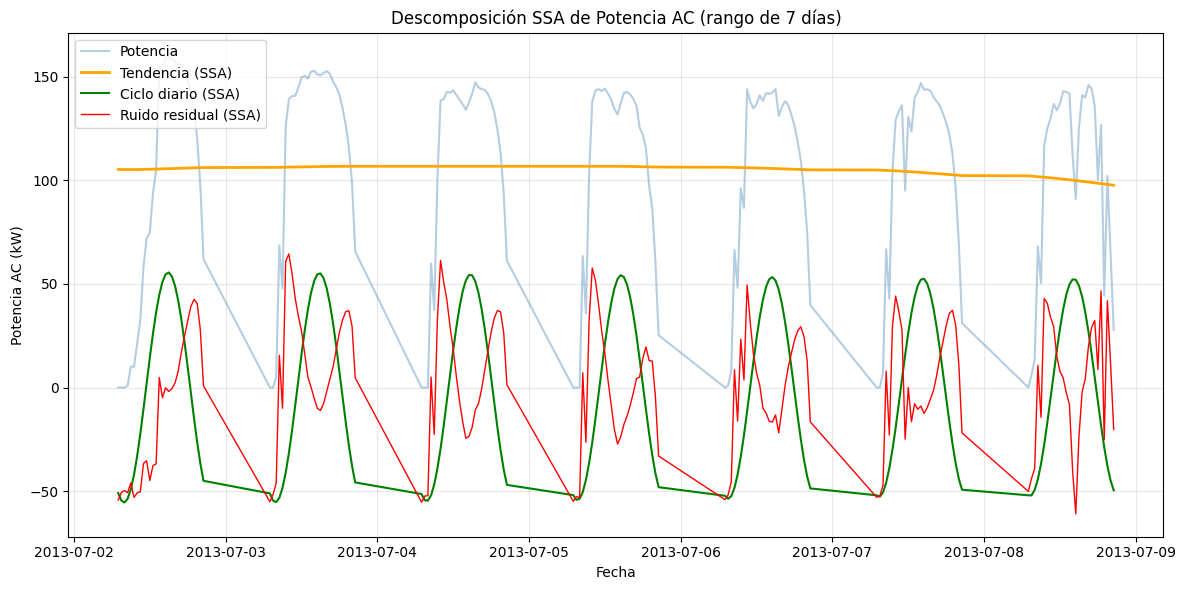

In [ ]:
fecha_inicio = '2013-07-02'
fecha_fin = '2013-07-09'

df_zoom = df_sub[(df_sub['fecha'] >= fecha_inicio) & (df_sub['fecha'] <= fecha_fin)]

plt.figure(figsize=(12,6))
plt.plot(df_zoom['fecha'], df_zoom['potencia_ac'], label='Potencia', color='steelblue', alpha=0.4)
plt.plot(df_zoom['fecha'], df_zoom['tendencia_potencia'], label='Tendencia (SSA)', color='orange', linewidth=2)
plt.plot(df_zoom['fecha'], df_zoom['periodo_potencia'], label='Ciclo diario (SSA)', color='green', linewidth=1.5)
plt.plot(df_zoom['fecha'], df_zoom['ruido_potencia'], label='Ruido residual (SSA)', color='red', linewidth=1)
plt.title("Descomposición SSA de Potencia AC (rango de 7 días)")
plt.xlabel("Fecha")
plt.ylabel("Potencia AC (kW)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Tras aplicar el método Singular Spectrum Analysis (SSA) a la serie de potencia AC, se obtuvieron tres componentes principales:

*  Una componente de tendencia (potencia_trend),

*  Una componente periódica asociada al ciclo diario (potencia_periodic),

*  Una componente de ruido residual (potencia_noise).

Debido a las limitaciones de memoria del entorno de trabajo, el SSA se aplicó sobre una submuestra de la serie temporal, tomando una observación cada 30 minutos. Este submuestreo permitió capturar la estructura general de la señal sin comprometer la estabilidad computacional del algoritmo. Sin embargo, el conjunto de datos original (df_final) contiene mediciones con una resolución temporal de 5 minutos, por lo que fue necesario reajustar y alinear las variables derivadas del SSA para integrarlas correctamente con el resto de los predictores.

Para ello, se interpolaron las componentes SSA a la frecuencia temporal original mediante interpolación lineal dependiente del tiempo (method='time'). Este procedimiento permitió estimar los valores intermedios entre cada punto de 30 minutos, reconstruyendo las señales de tendencia y periodicidad a intervalos de 5 minutos de manera continua y coherente con el comportamiento temporal del sistema fotovoltaico.

La inclusión de las variables tendencia_potencia y periodo_potencia en el dataset principal se justifica porque ambas representan información complementaria de la dinámica temporal del sistema, difícil de capturar mediante las variables originales.

En particular:

*  La variable tendencia_potencia describe el comportamiento de largo plazo de la generación, asociado a la evolución estacional o a variaciones graduales en la radiación solar y en las condiciones del módulo fotovoltaico.

*  La variable periodo_potencia refleja los ciclos diarios de generación, directamente vinculados con el patrón de radiación solar y la posición del sol a lo largo del día.

Al incorporar estas variables al conjunto original, el modelo predictivo adquiere la capacidad de distinguir entre fluctuaciones de corto y largo plazo, mejorando la representación de la estructura temporal.

Además, se decidió no incluir la componente de ruido (potencia_noise), ya que su naturaleza aleatoria no aporta información útil para el aprendizaje.

In [ ]:
df_final['fecha'] = pd.to_datetime(df_final['fecha'])
df_sub['fecha'] = pd.to_datetime(df_sub['fecha'])

# Definir columnas nuevas desde SSA
ssa_vars = ['tendencia_potencia', 'periodo_potencia']

# Crear DataFrame SSA con fecha como índice
df_ssa = df_sub[['fecha'] + ssa_vars].set_index('fecha')

#interpolar a los timestamps del df_final (5 min)
df_ssa_interp = df_ssa.reindex(df_final['fecha']).interpolate(method='time')

# Combinar con el DataFrame original
df_final = pd.concat([df_final.reset_index(drop=True),
                      df_ssa_interp.reset_index(drop=True)[ssa_vars]], axis=1)

# Verificar
df_final.head()

/tmp/ipython-input-3330515361.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['fecha'] = pd.to_datetime(df_final['fecha'])


,radiacion_solar,temperatura_modulo,tension_ac,tension_dc,fecha,fecha_completa,hora,dia_semana,mes,potencia_ac,tendencia_potencia,periodo_potencia
0,87.029147,16.367407,92.136134,9.188424,2013-01-02 07:00:00,2013-01-02,7,2,1,3.363817,81.276682,-61.931093
1,87.029147,16.367407,92.136134,9.188424,2013-01-02 07:05:00,2013-01-02,7,2,1,3.363817,81.290903,-60.377448
2,87.029147,16.367407,92.136134,9.188424,2013-01-02 07:10:00,2013-01-02,7,2,1,3.363817,81.305124,-58.823804
3,87.029147,16.367407,92.136134,9.188424,2013-01-02 07:15:00,2013-01-02,7,2,1,3.363817,81.319345,-57.270159
4,87.029147,16.367407,92.136134,9.188424,2013-01-02 07:20:00,2013-01-02,7,2,1,3.363817,81.333566,-55.716514


###Métodos no lineales

#### Creación de variables temporales

Con el objetivo de capturar la dinámica temporal inherente al proceso de generación de potencia, se incorporaron al conjunto de datos una serie de variables derivadas basadas en retardos temporales (lags), estadísticas móviles y transformaciones periódicas de la hora del día. Estas variables permiten representar explícitamente la dependencia temporal y la variabilidad diaria de la señal, aspectos fundamentales en series temporales de origen físico como las provenientes de sistemas fotovoltaicos.

In [ ]:
df_final['hora']=df_final['hora'].astype('float')

In [ ]:
df_final['hora_sin'] = np.sin(2 * np.pi * df_final['hora'] / 13)
df_final['hora_cos'] = np.cos(2 * np.pi * df_final['hora'] / 13)

La generación solar es periódica a lo largo de los días. Para representar esa periodicidad de manera continua, se transformó la variable “hora” en dos componentes trigonométricas

Estas variables codifican la posición angular de la hora dentro del ciclo diario (de 7:00 a 20:00), garantizando que las horas contiguas de días diferentes (es decir, 7 y 20) tengan representaciones similares en el espacio de características.

A diferencia de utilizar directamente la hora en formato numérico, esta codificación cíclica evita discontinuidades en los modelos y permite capturar de forma suave las variaciones periódicas de la radiación solar y, por tanto, de la potencia generada.

In [ ]:
# Retardo cada 15 minutos (lags)
df_final['P_lag3'] = df_final.groupby('fecha_completa')['potencia_ac'].shift(3)

# Retardo cada 30 minutos (lags)
df_final['P_lag6'] = df_final.groupby('fecha_completa')['potencia_ac'].shift(6)

# Retardo cada 60 minutos (lags)
df_final['P_lag12'] = df_final.groupby('fecha_completa')['potencia_ac'].shift(12)

# Promedio de ventanas de 30 minutos
df_final['P_roll_mean_30min'] = df_final['potencia_ac'].rolling(window=6,min_periods=1).mean()

# Minimo de ventanas de 30 minutos
df_final['P_roll_min_30min'] = df_final['potencia_ac'].rolling(window=6, min_periods=1).min()

#Maximo de ventanas de 30 minutos
df_final['P_roll_max_30min'] = df_final['potencia_ac'].rolling(window=6, min_periods=1).max()

#Promedio de ventanas de 1 hora
df_final['P_roll_mean_1h'] = df_final['potencia_ac'].rolling(window=12, min_periods=1).mean()

#Desviacion de ventanas de 30 minutos
df_final['P_roll_std_30min'] = df_final['potencia_ac'].rolling(window=6, min_periods=1).std()

#Desviacion de ventanas de 1 hora
df_final['P_roll_std_1h'] = df_final['potencia_ac'].rolling(window=12, min_periods=1).std()

Los promedios móviles (P_roll_mean_15min, P_roll_mean_30min, P_roll_mean_1h) suavizan la señal y representan la potencia típica reciente, ayudando a filtrar fluctuaciones puntuales.

Los valores mínimos y máximos móviles (P_roll_min_30min, P_roll_max_30min) capturan el rango operativo de la planta en períodos cortos, útil para detectar posibles saturaciones o caídas en la generación.

Las desviaciones estándar móviles (P_roll_std_30min, P_roll_std_1h) cuantifican la variabilidad local, reflejando la estabilidad atmosférica o la intermitencia solar.

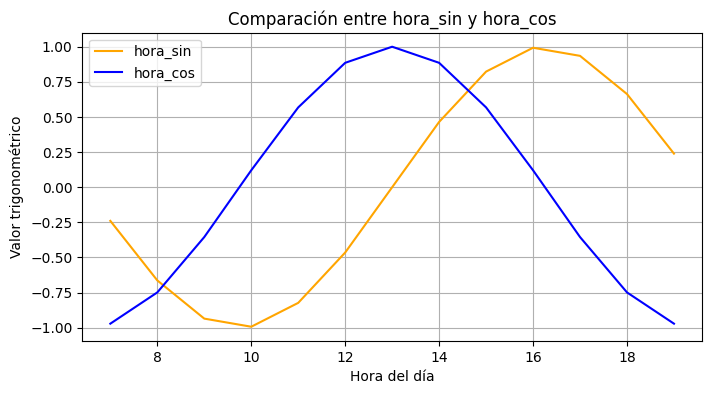

/tmp/ipython-input-1230020458.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('hora')['potencia_ac'].mean().plot(color='green', marker='o', label='Potencia media')


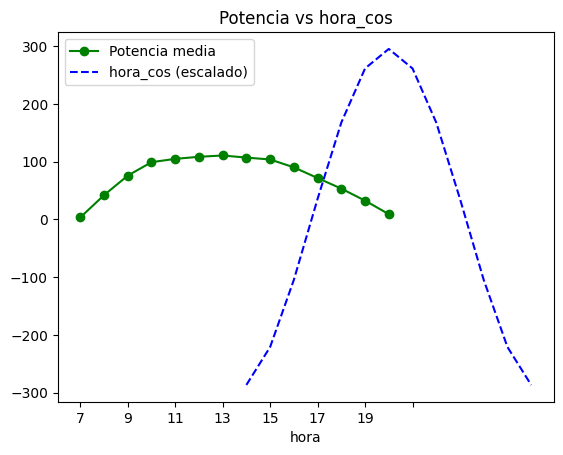

In [ ]:
# Curvas teóricas
horas = np.arange(7, 20)
hora_sin = np.sin(2 * np.pi * horas / 13)
hora_cos = np.cos(2 * np.pi * horas / 13)

plt.figure(figsize=(8,4))
plt.plot(horas, hora_sin, label='hora_sin', color='orange')
plt.plot(horas, hora_cos, label='hora_cos', color='blue')
plt.title("Comparación entre hora_sin y hora_cos")
plt.xlabel("Hora del día")
plt.ylabel("Valor trigonométrico")
plt.legend()
plt.grid(True)
plt.show()

df.groupby('hora')['potencia_ac'].mean().plot(color='green', marker='o', label='Potencia media')
plt.plot(horas, hora_cos * df_final['potencia_ac'].max(), '--', color='blue', label='hora_cos (escalado)')
plt.legend()
plt.title("Potencia vs hora_cos")
plt.show()


In [ ]:
df_final['mes']=df_final['mes'].astype('object')
df_final['dia_semana']=df_final['dia_semana'].astype('object')

In [ ]:
df_final=df_final.fillna(0)

/tmp/ipython-input-2848008480.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_final=df_final.fillna(0)


#### XGBoost

Con el fin de evaluar la relevancia de las variables creadas durante el proceso de ingeniería de características y determinar su capacidad explicativa sobre la generación eléctrica, se implementó el algoritmo XGBoost (Extreme Gradient Boosting) como método no lineal de extracción de caracteristicas.

Este modelo pertenece a la familia de los métodos de ensamble basados en árboles de decisión, y se caracteriza por combinar múltiples árboles débiles de forma secuencial, donde cada nuevo árbol corrige los errores cometidos por los anteriores. Gracias a este enfoque, XGBoost logra un excelente equilibrio entre precisión, interpretabilidad y eficiencia computacional, lo que lo convierte en una herramienta idónea tanto para predicción como para análisis de importancia de variables.

El sistema fotovoltaico presenta un comportamiento altamente no lineal, influenciado por múltiples factores ambientales y eléctricos (radiación solar, temperatura, tensiones, hora del día, sombreados, etc.).
Los modelos lineales tradicionales, no son capaces de capturar adecuadamente las interacciones complejas y no aditivas entre estas variables.

XGBoost, en cambio:

*  No requiere supuestos de linealidad ni de normalidad de los datos.

*  Captura interacciones no lineales entre variables predictoras.

*  Permite manejar datos correlacionados y escalas diferentes.

*  Ofrece una estimación directa de la importancia de las variables, medida por su contribución al proceso de decisión.

In [ ]:
df_final.head()

,radiacion_solar,temperatura_modulo,tension_ac,tension_dc,fecha,fecha_completa,hora,dia_semana,mes,potencia_ac,...,hora_cos,P_lag3,P_lag6,P_lag12,P_roll_mean_30min,P_roll_min_30min,P_roll_max_30min,P_roll_mean_1h,P_roll_std_30min,P_roll_std_1h
0,87.029147,16.367407,92.136134,9.188424,2013-01-02 07:00:00,2013-01-02,7.0,2,1,3.363817,...,-0.970942,0.000000,0.0,0.0,3.363817,3.363817,3.363817,3.363817,0.0,0.0
1,87.029147,16.367407,92.136134,9.188424,2013-01-02 07:05:00,2013-01-02,7.0,2,1,3.363817,...,-0.970942,0.000000,0.0,0.0,3.363817,3.363817,3.363817,3.363817,0.0,0.0
2,87.029147,16.367407,92.136134,9.188424,2013-01-02 07:10:00,2013-01-02,7.0,2,1,3.363817,...,-0.970942,0.000000,0.0,0.0,3.363817,3.363817,3.363817,3.363817,0.0,0.0
3,87.029147,16.367407,92.136134,9.188424,2013-01-02 07:15:00,2013-01-02,7.0,2,1,3.363817,...,-0.970942,3.363817,0.0,0.0,3.363817,3.363817,3.363817,3.363817,0.0,0.0
4,87.029147,16.367407,92.136134,9.188424,2013-01-02 07:20:00,2013-01-02,7.0,2,1,3.363817,...,-0.970942,3.363817,0.0,0.0,3.363817,3.363817,3.363817,3.363817,0.0,0.0


In [ ]:
df = df_final.copy()
df = df.sort_values('fecha').reset_index(drop=True)

In [ ]:
import pandas as pd
import sqlite3
import gdown
from google.colab import drive
drive.mount('/content/drive')
conn = sqlite3.connect("/content/drive/MyDrive/Analítica_David/data_final.db")
df.to_sql("df", conn, if_exists="replace", index=False)
conn.close()

Mounted at /content/drive


Se entrenaron dos modelos independientes de XGBoost, ajustados al mismo conjunto de variables pero con distintos horizontes de predicción:

Modelo de 5 minutos: predice la potencia en el corto plazo (target_5min) a partir de las condiciones actuales.

Modelo de 30 minutos: predice la potencia futura (target_30min), agregando mayor horizonte temporal.

In [ ]:
# Potencia 5 min adelante (un paso)
df['target_5min'] = df['potencia_ac'].shift(-1)

# Potencia 30 min adelante (6 pasos)
df['target_30min'] = df['potencia_ac'].shift(-6)

# Eliminar filas sin valor futuro
df = df.dropna(subset=['target_5min', 'target_30min'])


In [ ]:
features_5min = [
    'radiacion_solar', 'temperatura_modulo', 'tension_ac', 'tension_dc',
    'hora_sin', 'hora_cos',
    'P_lag3',
    'P_roll_mean_30min', 'P_roll_std_30min', 'P_roll_mean_1h', 'P_roll_std_1h',
    'tendencia_potencia', 'periodo_potencia'
]

In [ ]:
features_30min = [
    'radiacion_solar', 'temperatura_modulo', 'tension_ac', 'tension_dc',
    'hora_sin', 'hora_cos', 'mes', 'dia_semana',
    'P_lag3', 'P_lag6', 'P_lag12',
    'P_roll_min_30min', 'P_roll_max_30min', 'P_roll_mean_1h', 'P_roll_std_1h',
    'tendencia_potencia', 'periodo_potencia'
]

In [ ]:
X5 = df[features_5min]
y5 = df['target_5min']

X30 = df[features_30min]
y30 = df['target_30min']

# División 80% entrenamiento / 20% validación
split_idx = int(len(df)*0.8)
X5_train, X5_val = X5.iloc[:split_idx], X5.iloc[split_idx:]
y5_train, y5_val = y5.iloc[:split_idx], y5.iloc[split_idx:]

X30_train, X30_val = X30.iloc[:split_idx], X30.iloc[split_idx:]
y30_train, y30_val = y30.iloc[:split_idx], y30.iloc[split_idx:]

In [ ]:
# Convertir a DMatrix
D_train_5 = xgb.DMatrix(X5_train,  label=y5_train,  feature_names=list(X5_train.columns))
D_valid_5 = xgb.DMatrix(X5_val,    label=y5_val,    feature_names=list(X5_val.columns))
D_train_30 = xgb.DMatrix(X30_train, label=y30_train, feature_names=list(X30_train.columns))
D_valid_30 = xgb.DMatrix(X30_val,   label=y30_val,   feature_names=list(X30_val.columns))

In [ ]:
#Parametros del modelo
params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse', #métrica
    'eta': 0.2, #tasa de aprendizaje
    'max_depth': 8, # Profundidad máxima de cada árbol
    'subsample': 0.8, #porcentaje de datos muestrados en cada iteración
    'colsample_bytree': 0.7, #columnas seleccionadas para cada arbol
    'min_child_weight': 300, #número mínimo de muestras en un nodo hoja
    'tree_method': 'hist',
    'seed': 42
}
#Para evitar el sobreajuste y optimizar el numero de iteraciones
# Early stopping callback
early_stop = EarlyStopping(
    rounds=25,
    save_best=True,
    metric_name='rmse',
    data_name='Valid'
)
#Este callback detiene automáticamente el entrenamiento si la métrica de error (RMSE) no mejora durante 25 iteraciones consecutivas,
#conservando el mejor modelo alcanzado

#Entrenamiento del modelo para predecir cada 5 minutos

modelo_5min = xgb.train(
    params=params,
    dtrain=D_train_5,
    num_boost_round=400,
    evals=[(D_train_5, 'Train'), (D_valid_5, 'Valid')],
    callbacks=[early_stop],
    verbose_eval=False
)
#Entrenamiento del modelo para predecir cada 30 minutos

early_stop_30 = xgb.callback.EarlyStopping(
    rounds=25,
    save_best=True,
    metric_name='rmse',
    data_name='Valid',
    maximize=False
)

modelo_30min = xgb.train(
    params=params,
    dtrain=D_train_30,
    num_boost_round=400,
    evals=[(D_train_30, 'Train'), (D_valid_30, 'Valid')],
    callbacks=[early_stop_30],
    verbose_eval=False
)

#Desempeño de los modelos
# Predicciones
pred_5min = modelo_5min.predict(D_valid_5)
pred_30min = modelo_30min.predict(D_valid_30)

# RMSE
rmse_5 = sqrt(mean_squared_error(y5_val, pred_5min))
rmse_30 = sqrt(mean_squared_error(y30_val, pred_30min))

print(f"Resultados del modelo:")
print(f"RMSE (5 min) = {rmse_5:.4f}")
print(f"RMSE (30 min) = {rmse_30:.4f}")



Resultados del modelo:
RMSE (5 min) = 11.8384
RMSE (30 min) = 21.9586


El entrenamiento se realizó mediante un esquema de validación temporal, separando los datos de entrenamiento y validación en función del tiempo para mantener la coherencia cronológica.

Como métrica de evaluación se empleó el error cuadrático medio (RMSE), adecuado para cuantificar la desviación media entre los valores predichos y los reales de potencia.

El análisis de importancia de variables (feature importance) se realizó utilizando dos criterios disponibles en XGBoost:

*  Weight= número de veces que una variable aparece en los árboles.
*  Gain= incremento promedio en la reducción del error cuando se usa la variable.

Importancia de variables (modelo 5 min)


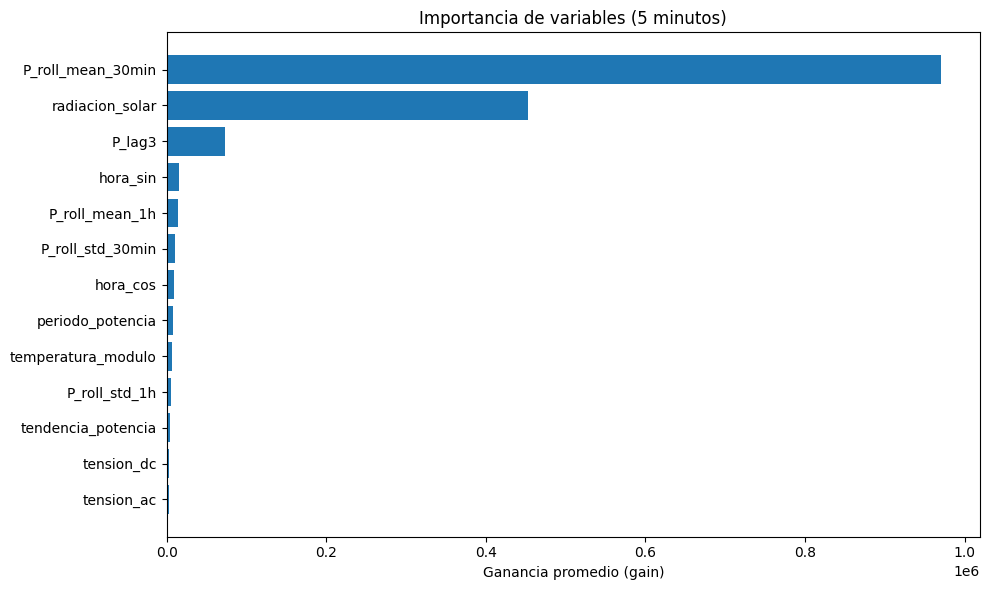

Importancia de variables (modelo 30 min)


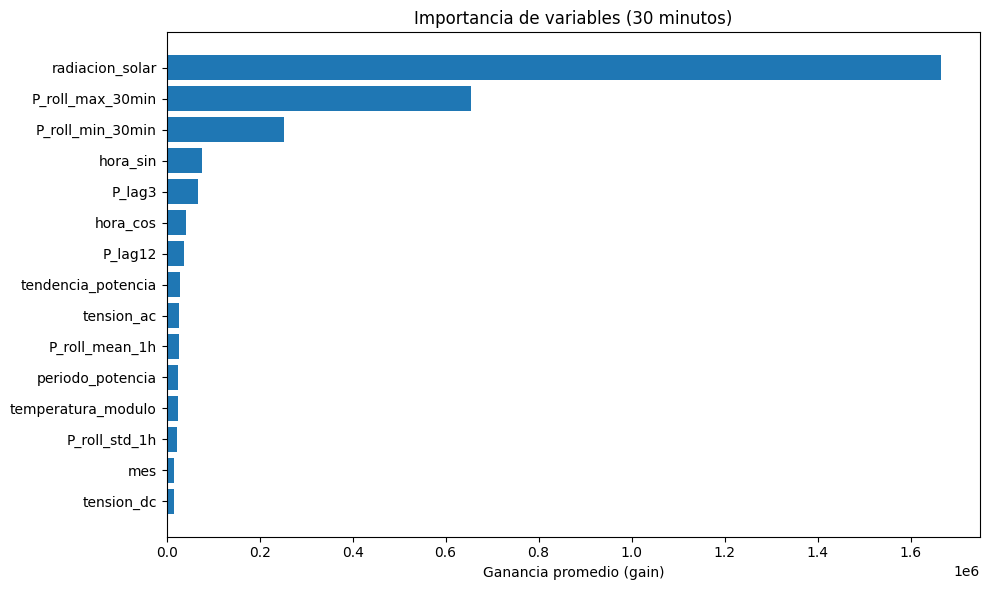

In [ ]:
# Importancia de variables (Feature Extraction)

def plot_feature_importance(booster, top_n=15, title="Importancia de variables"):
    importance = booster.get_score(importance_type='gain')
    imp_df = pd.DataFrame({
        'feature': list(importance.keys()),
        'gain': list(importance.values())
    }).sort_values(by='gain', ascending=False)

    plt.figure(figsize=(10,6))
    plt.barh(imp_df['feature'].head(top_n)[::-1], imp_df['gain'].head(top_n)[::-1])
    plt.xlabel('Ganancia promedio (gain)')
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return imp_df

print("Importancia de variables (modelo 5 min)")
imp_5 = plot_feature_importance(modelo_5min, top_n=15, title="Importancia de variables (5 minutos)")

print("Importancia de variables (modelo 30 min)")
imp_30 = plot_feature_importance(modelo_30min, top_n=15, title="Importancia de variables (30 minutos)")


En el modelo de predicción a 5 minutos, las tres variables más relevantes fueron:

P_roll_mean_30min: presenta la mayor ganancia, lo que indica que el promedio móvil de la potencia en los últimos 30 minutos es el mejor predictor del valor futuro inmediato.
Esto refleja la alta persistencia temporal del sistema fotovoltaico, donde la potencia actual depende fuertemente de su comportamiento reciente.

radiacion_solar: la segunda variable más importante, confirma que la irradiancia solar es el principal factor externo que impulsa la generación eléctrica. Su alta correlación física con la potencia explica su peso dominante.

P_lag3 (retardo de 15 minutos): aporta información adicional sobre la inercia temporal de la serie, capturando pequeñas fluctuaciones de corto plazo que el promedio móvil no representa del todo.

Variables como P_roll_mean_1h, P_roll_std_30min o las transformaciones cíclicas de la hora (hora_sin, hora_cos) tuvieron una importancia secundaria.

Esto se debe a que, en horizontes muy cortos, la variación diaria aún no genera cambios significativos, por lo que la predicción depende casi exclusivamente de la tendencia reciente de la potencia y la radiación solar.

En el horizonte de 30 minutos, la jerarquía de importancia cambia:

radiacion_solar: es la variable más determinante, lo que confirma su papel como variable exógena fundamental. La irradiancia define la magnitud global de la potencia generada, especialmente en horizontes mayores, donde los efectos de la variabilidad atmosférica (paso de nubes, cambios de luminosidad) se amplifican.

P_roll_max_30min y P_roll_min_30min: estas variables, que capturan los valores extremos de potencia en la ventana reciente, adquieren relevancia al reflejar la amplitud de variación dentro de los últimos 30 minutos. Son indicativas de la estabilidad o intermitencia del sistema.

Variables temporales (hora_sin, hora_cos): comienzan a mostrar un peso más visible, lo que indica que a horizontes de 30 minutos la posición solar y el momento del día influyen significativamente en la predicción.

tendencia_potencia (SSA): aunque con menor ganancia que las variables principales, su inclusión contribuye a capturar el componente de largo plazo en la potencia, mejorando la estabilidad del modelo frente a variaciones estacionales.

Importancia de variables (modelo 5 min)


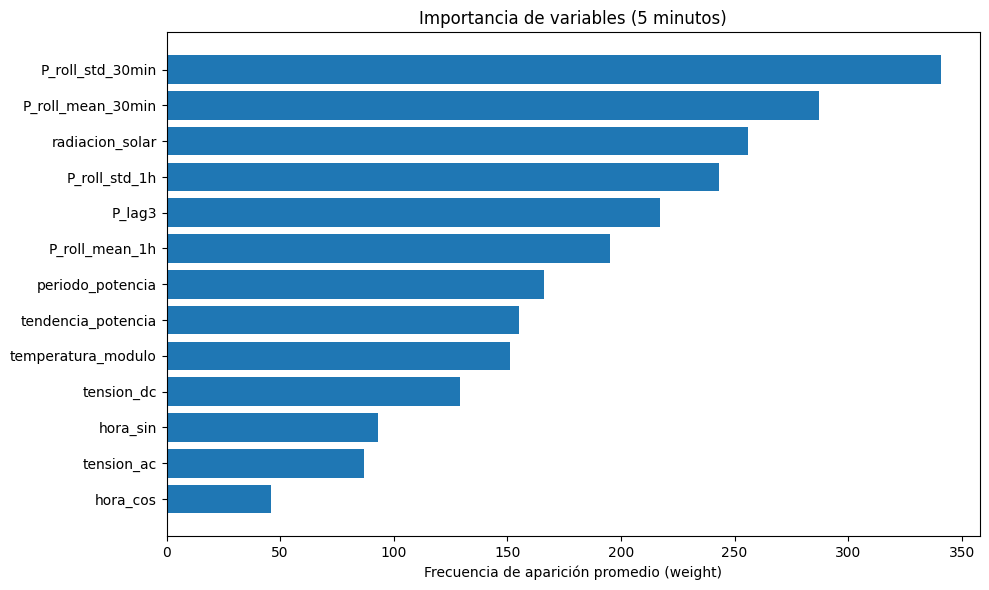

Importancia de variables (modelo 30 min)


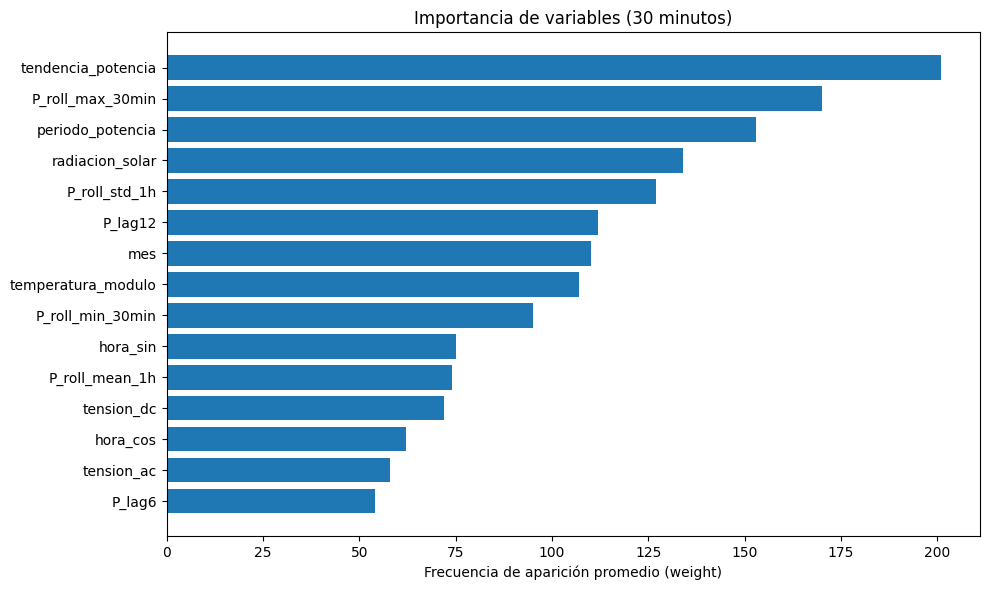

In [ ]:
# Importancia de variables (Feature Extraction)

def plot_feature_importance(booster, top_n=15, title="Importancia de variables"):
    importance = booster.get_score(importance_type='weight')
    imp_df = pd.DataFrame({
        'feature': list(importance.keys()),
        'weight': list(importance.values())
    }).sort_values(by='weight', ascending=False)

    plt.figure(figsize=(10,6))
    plt.barh(imp_df['feature'].head(top_n)[::-1], imp_df['weight'].head(top_n)[::-1])
    plt.xlabel('Frecuencia de aparición promedio (weight)')
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return imp_df

print("Importancia de variables (modelo 5 min)")
imp_5 = plot_feature_importance(modelo_5min, top_n=15, title="Importancia de variables (5 minutos)")

print("Importancia de variables (modelo 30 min)")
imp_30 = plot_feature_importance(modelo_30min, top_n=15, title="Importancia de variables (30 minutos)")


En el modelo de predicción a 5 minutos, las variables con mayor frecuencia de aparición fueron:

P_roll_std_30min y P_roll_mean_30min: ambas lideran el ranking, lo que indica que el modelo depende constantemente de las estadísticas móviles recientes (promedio y variabilidad) para anticipar la potencia inmediata.
Su frecuencia elevada refleja que las fluctuaciones de corto plazo (cambios en irradiancia) son claves para predecir el comportamiento en el siguiente intervalo.

radiacion_solar: aparece con alta frecuencia, reafirmando que la irradiancia sigue siendo el principal impulsor físico del sistema.

P_lag3, P_roll_mean_1h y P_roll_std_1h: contribuyen de manera complementaria capturando el efecto de inercia temporal y la suavización de la señal a escalas mayores.

Variables como tendencia_potencia (SSA) o temperatura_modulo presentan un uso moderado, lo que sugiere que, en predicciones tan cortas, su aporte es secundario.

En el horizonte de 30 minutos, la dinámica cambia y el modelo da mayor peso a variables que describen tendencias y patrones diarios:

tendencia_potencia (SSA): es la variable más utilizada en los árboles, lo que evidencia que la componente de tendencia extraída mediante SSA se convierte en un indicador dominante del comportamiento a mediano plazo.

P_roll_max_30min, P_roll_min_30min y P_roll_std_1h: representan la dispersión y los extremos recientes de la potencia, útiles para modelar la estabilidad o intermitencia del sistema fotovoltaico.

periodo_potencia (SSA) y radiacion_solar: refuerzan el patrón cíclico diario, reflejando la dependencia de la potencia con el ciclo solar y los efectos de la nubosidad.

Las variables temporales (hora_sin, hora_cos, mes) adquieren una frecuencia de uso intermedia, indicando que el modelo reconoce los efectos horarios y estacionales sobre la generación a este horizonte temporal.

In [ ]:
#Predicciones
pred_5 = modelo_5min.predict(D_valid_5)
pred_30 = modelo_30min.predict(D_valid_30)

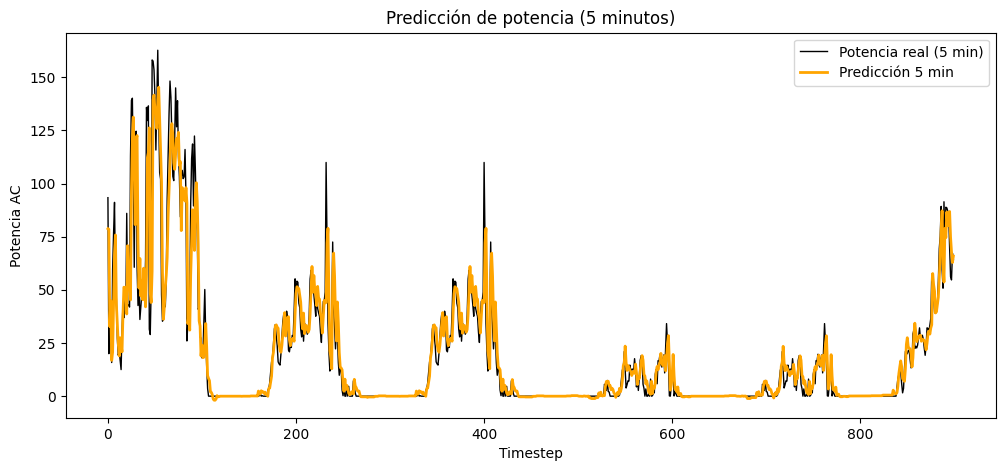

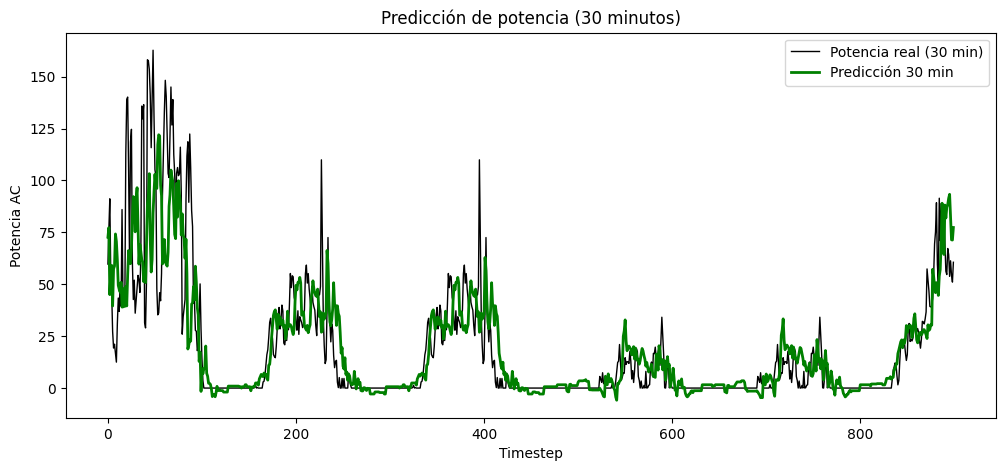

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y5_val.values[:900], label="Potencia real (5 min)", color="black", linewidth=1)
plt.plot(pred_5[:900], label="Predicción 5 min", color="orange", linewidth=2)
plt.title("Predicción de potencia (5 minutos)")
plt.xlabel("Timestep")
plt.ylabel("Potencia AC")
plt.legend()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(y30_val.values[:900], label="Potencia real (30 min)", color="black", linewidth=1)
plt.plot(pred_30[:900], label="Predicción 30 min", color="green", linewidth=2)
plt.title("Predicción de potencia (30 minutos)")
plt.xlabel("Timestep")
plt.ylabel("Potencia AC")
plt.legend()
plt.show()


El modelo de 5 minutos alcanzó errores menores, como era de esperarse, debido a la fuerte correlación temporal entre muestras consecutivas; el modelo de 30 minutos, en cambio, presentó un error ligeramente mayor, reflejando la mayor incertidumbre en horizontes más largos.

Los resultados obtenidos fueron consistentes con la naturaleza del proceso físico: las predicciones se ajustan bien a los periodos de alta radiación solar y muestran mayor dispersión en las transiciones entre día y noche, donde la generación varía más abruptamente.

#Conclusiones

En este trabajo se combinaron diferentes técnicas de selección y extracción de características con el fin de identificar las variables más relevantes e informativas para la posterior predicción de la potencia generada en el sistema fotovoltaico. Primero se aplicaron métodos lineales como el umbral de varianza, la correlación de Pearson y la selección secuencial hacia adelante, con los que se identificaron las variables más relevantes y se eliminaron aquellas que aportaban información redundante. Luego se exploraron métodos de reducción de dimensionalidad como el PCA y el SSA. Mientras que el PCA ayudó a entender las relaciones lineales entre las variables, el SSA resultó más apropiado para este tipo de datos, ya que permitió descomponer la serie de potencia en tres componentes principales: tendencia, ciclo diario y ruido, mostrando con claridad el comportamiento temporal del sistema.

Por último, se utilizaron modelos no lineales basados en XGBoost para predecir la potencia a intervalos de 5 y 30 minutos, lo que permitió evaluar la importancia de cada variable en la predicción. Los resultados mostraron que las variables más influyentes fueron la radiación solar, la temperatura del módulo, variables creadas en el SSA como: la tendencia y el periodo, el retardo de 15 minutos y las variables generadas a partir de promedios y desviaciones móviles en una ventana de 30 minutos, también se encontró mejor desempeño en el modelo que predice la potencia en un intervalo de 5 minutos. En conjunto, la metodología implementada permitió representar de manera precisa el comportamiento del sistema fotovoltaico, demostrando que la combinación de técnicas lineales y no lineales es una estrategia efectiva para el análisis de series temporales en energía solar fotovoltaica.